In [1]:
import numpy as np
import pandas as pd
data = np.load("../data/processed/FULL_30.npz", allow_pickle=True)
X_full = data["X"]

train = np.load("../data/processed/TRAIN_30.npz", allow_pickle=True)

X_train = train["X"]
y_train = train["y"]

df = pd.DataFrame(X_full, columns=[f"F{i}" for i in range(1,31)])


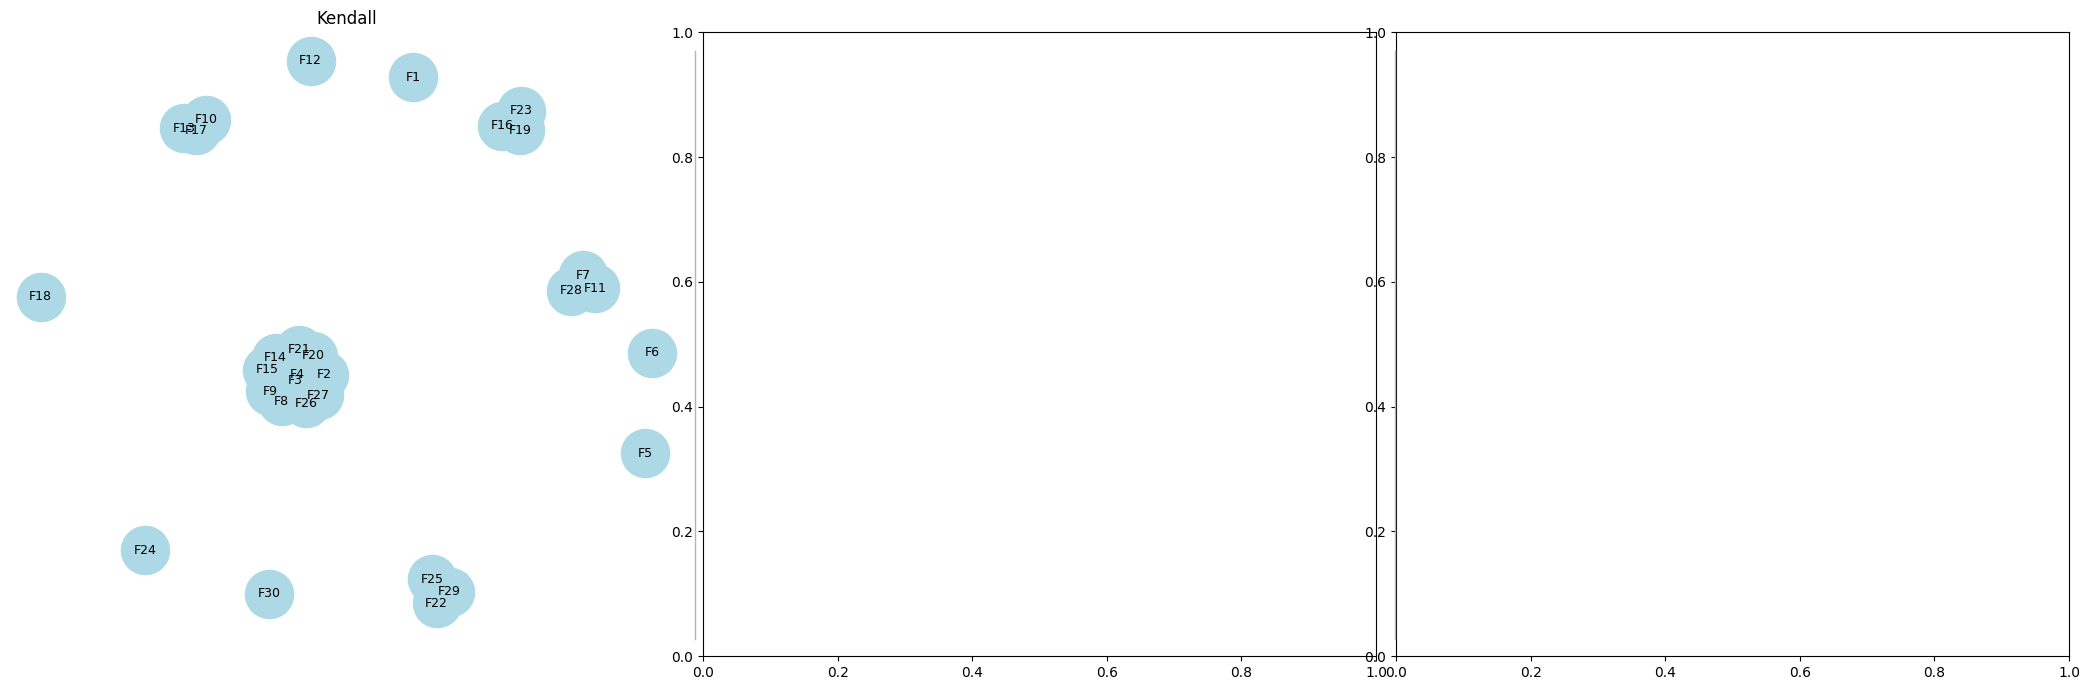

In [2]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import networkx as nx

corr_methods = {
    # "Pearson": df.corr().abs(),
    # "Spearman": df.corr(method="spearman").abs(),
    "Kendall": df.corr(method="kendall").abs()
}

threshold = 0.8

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (name, corr) in zip(axes, corr_methods.items()):
    G = nx.Graph()

    for col in df.columns:
        G.add_node(col)

    for i in range(len(df.columns)):
        for j in range(i + 1, len(df.columns)):
            if corr.iloc[i, j] > threshold:
                G.add_edge(
                    df.columns[i],
                    df.columns[j],
                    weight=corr.iloc[i, j]
                )

    pos = nx.spring_layout(G, seed=0)

    weights = [d["weight"] * 3 for _, _, d in G.edges(data=True)]

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        width=weights,
        node_size=1200,
        node_color="lightblue",
        font_size=9,
    )

    ax.set_title(name)


plt.tight_layout()
fig.subplots_adjust(wspace=0.03)

for x in [1/3, 2/3]:
    fig.add_artist(
        Line2D(
            [x, x],
            [0.08, 0.92],
            transform=fig.transFigure,
            color="0.7",
            linewidth=1
        )
    )
plt.savefig(
    "feature_correlation_graphs.png",
    dpi=300,
)

plt.show()

In [3]:
plt.savefig(
    "feature_correlation_graphs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [4]:
groups = []
for comp in nx.connected_components(G):
    if len(comp) > 1:
        groups.append(comp)
        print(sorted(comp))

['F14', 'F15', 'F2', 'F20', 'F21', 'F26', 'F27', 'F3', 'F4', 'F8', 'F9']
['F11', 'F28', 'F7']
['F10', 'F13', 'F17']
['F16', 'F19', 'F23']
['F22', 'F25', 'F29']


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
group1 = sorted(groups[0])

group1_pc = pca.fit_transform(df[group1])

In [6]:

for i, group in enumerate(groups):
    cols = list(group)

    pca = PCA(n_components=1)
    pca.fit(df[cols])

    print(
        f"Group {i+1}: "
        f"{len(cols)} features -> "
        f"PC1 explains {pca.explained_variance_ratio_[0]:.3f}"
    )

Group 1: 11 features -> PC1 explains 0.998
Group 2: 3 features -> PC1 explains 1.000
Group 3: 3 features -> PC1 explains 1.000
Group 4: 3 features -> PC1 explains 1.000
Group 5: 3 features -> PC1 explains 1.000


In [7]:
for i, group in enumerate(groups):
    pca = PCA(n_components=1)
    pca.fit(df[list(group)])

    print(
        f"Group {i+1}: "
        f"{pca.explained_variance_ratio_[0]:.10f}"
    )

Group 1: 0.9977904290
Group 2: 0.9999985629
Group 3: 0.9999985633
Group 4: 0.9999985676
Group 5: 0.9999985562


In [8]:
for group in groups:

    group_list = list(group) 
    
    pca = PCA(n_components=1)
    pca.fit(df[group_list])
    
    loadings = pd.Series(
        np.abs(pca.components_[0]),
        index=group
    ).sort_values(ascending=False)
    
    print(loadings)

F3     0.862764
F4     0.431321
F2     0.215845
F14    0.053737
F15    0.053687
F20    0.053679
F21    0.053645
F26    0.053620
F9     0.053604
F27    0.053554
F8     0.053532
dtype: float64
F7     0.688837
F28    0.688837
F11    0.225846
dtype: float64
F13    0.688837
F10    0.688837
F17    0.225845
dtype: float64
F16    0.688837
F19    0.688837
F23    0.225848
dtype: float64
F25    0.688838
F22    0.688838
F29    0.225844
dtype: float64


In [9]:
representatives = []

for group in groups:
    group_list = list(group)

    pca = PCA(n_components=1)
    pca.fit(df[group_list])

    loadings = pd.Series(
        np.abs(pca.components_[0]),
        index=group_list
    )

    representative = loadings.idxmax()
    representatives.append(representative)

    print(f"Group: {sorted(group_list)}")
    print(f"Representative: {representative}")

Group: ['F14', 'F15', 'F2', 'F20', 'F21', 'F26', 'F27', 'F3', 'F4', 'F8', 'F9']
Representative: F3
Group: ['F11', 'F28', 'F7']
Representative: F7
Group: ['F10', 'F13', 'F17']
Representative: F13
Group: ['F16', 'F19', 'F23']
Representative: F16
Group: ['F22', 'F25', 'F29']
Representative: F25


In [10]:
representatives = []

for group in groups:
    cols = list(group)

    corr = df[cols].corr().abs()

    mean_corr = corr.mean(axis=1)

    rep = mean_corr.idxmax()

    representatives.append(rep)

    print(f"Group: {sorted(cols)}")
    print(f"Representative: {rep}")
    print()

Group: ['F14', 'F15', 'F2', 'F20', 'F21', 'F26', 'F27', 'F3', 'F4', 'F8', 'F9']
Representative: F4

Group: ['F11', 'F28', 'F7']
Representative: F7

Group: ['F10', 'F13', 'F17']
Representative: F10

Group: ['F16', 'F19', 'F23']
Representative: F19

Group: ['F22', 'F25', 'F29']
Representative: F22



In [11]:
from sklearn.decomposition import PCA

representatives = []

for group in groups:
    cols = list(group)

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(df[cols]).ravel()

    corr_with_pc1 = {
        col: abs(np.corrcoef(df[col], pc1)[0,1])
        for col in cols
    }

    rep = max(corr_with_pc1, key=corr_with_pc1.get)

    representatives.append(rep)

    print(rep)

F3
F7
F10
F19
F22


In [12]:
grouped_features = set().union(*groups)

isolated = [
    col for col in df.columns
    if col not in grouped_features
]

selected_features = representatives + isolated

print(selected_features)
print(len(selected_features))

['F3', 'F7', 'F10', 'F19', 'F22', 'F1', 'F5', 'F6', 'F12', 'F18', 'F24', 'F30']
12
